In [ ]:
import pandas as pd
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer

in_path = "/Charlottesvilleprecipitation.csv"
out_path = "/content/charlottesville_precipitation.csv"

df = pd.read_csv(in_path)
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6904 entries, 0 to 6903
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       6904 non-null   object 
 1   TMAX (Degrees Fahrenheit)  6874 non-null   float64
 2   TMIN (Degrees Fahrenheit)  6873 non-null   float64
 3   PRCP (Inches)              6875 non-null   float64
dtypes: float64(3), object(1)
memory usage: 215.9+ KB


,TMAX (Degrees Fahrenheit),TMIN (Degrees Fahrenheit),PRCP (Inches)
count,6874.000000,6873.000000,6875.000000
mean,65.160023,48.916776,0.128356
std,16.522100,16.094790,0.368412
min,13.000000,-1.000000,0.000000
25%,53.000000,36.000000,0.000000
50%,67.000000,50.000000,0.000000
75%,79.000000,63.000000,0.040000
max,98.000000,80.000000,4.780000


In [ ]:
df[df['PRCP (Inches)'].isnull()]


,Date,TMAX (Degrees Fahrenheit),TMIN (Degrees Fahrenheit),PRCP (Inches)
1302,10/22/2010,NaN,NaN,NaN
1479,4/17/2011,NaN,NaN,NaN
1875,5/17/2012,NaN,NaN,NaN
2257,6/3/2013,NaN,NaN,NaN
2512,2/13/2014,34.0,20.0,NaN
2513,2/14/2014,51.0,31.0,NaN
2958,5/5/2015,NaN,NaN,NaN
4171,8/30/2018,NaN,NaN,NaN
4172,8/31/2018,NaN,NaN,NaN
4173,9/1/2018,NaN,NaN,NaN


In [ ]:
df = df.dropna(subset=['PRCP (Inches)'])
df['PRCP (Inches)'].isnull().sum()

np.int64(0)

In [ ]:
df[df['TMAX (Degrees Fahrenheit)'].isnull()]

,Date,TMAX (Degrees Fahrenheit),TMIN (Degrees Fahrenheit),PRCP (Inches)
245,11/30/2007,NaN,NaN,0.00
573,10/23/2008,NaN,NaN,0.00
920,10/5/2009,NaN,NaN,0.00
2642,6/23/2014,NaN,NaN,0.00
3199,1/1/2016,NaN,NaN,0.00
3555,12/22/2016,NaN,NaN,0.00
3703,5/19/2017,NaN,NaN,0.00
4057,5/8/2018,NaN,NaN,0.00
4419,5/5/2019,NaN,NaN,0.20
5618,8/16/2022,NaN,NaN,0.50


In [ ]:
df = df.dropna(subset=['TMAX (Degrees Fahrenheit)'])
df = df.dropna(subset=['TMIN (Degrees Fahrenheit)'])
df.info()
df.to_csv("/content/charlottesville_precip_cleaned.csv", index=False)




<class 'pandas.core.frame.DataFrame'>
Index: 6863 entries, 0 to 6894
Data columns (total 4 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       6863 non-null   object 
 1   TMAX (Degrees Fahrenheit)  6863 non-null   float64
 2   TMIN (Degrees Fahrenheit)  6863 non-null   float64
 3   PRCP (Inches)              6863 non-null   float64
dtypes: float64(3), object(1)
memory usage: 268.1+ KB


In [ ]:
percent_zero = (df['PRCP (Inches)'] == 0).mean() * 100
print(f"Percentage of precipitation values that are 0: {percent_zero:.2f}%")

Percentage of precipitation values that are 0: 67.61%


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df['month'] = df['Date'].dt.month
monthly_total = df.groupby('month')['PRCP (Inches)'].sum()
print(monthly_total)

highest_month = monthly_total.idxmax()
lowest_month = monthly_total.idxmin()

print("Highest total rainfall month:", highest_month)
print("Lowest total rainfall month:", lowest_month)


month
1     64.57
2     54.60
3     63.50
4     76.12
5     96.46
6     76.22
7     80.72
8     71.96
9     85.03
10    76.79
11    59.60
12    75.20
Name: PRCP (Inches), dtype: float64
Highest total rainfall month: 5
Lowest total rainfall month: 2


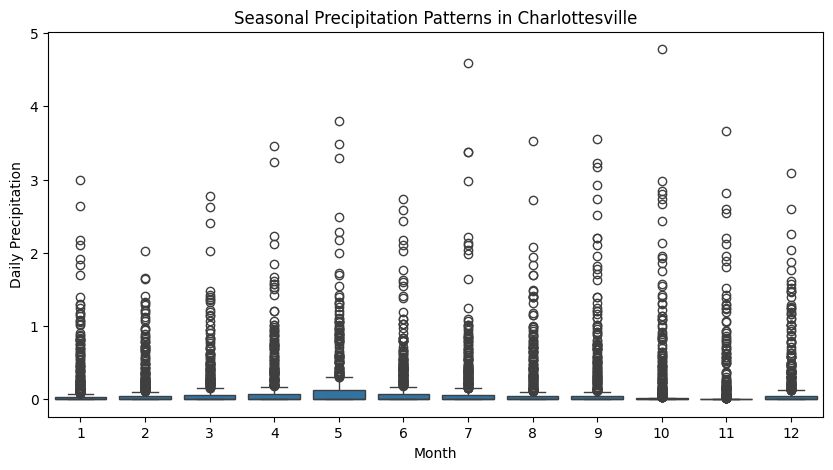

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x='month', y='PRCP (Inches)', data=df)
plt.title("Seasonal Precipitation Patterns in Charlottesville")
plt.xlabel("Month")
plt.ylabel("Daily Precipitation")
plt.show()

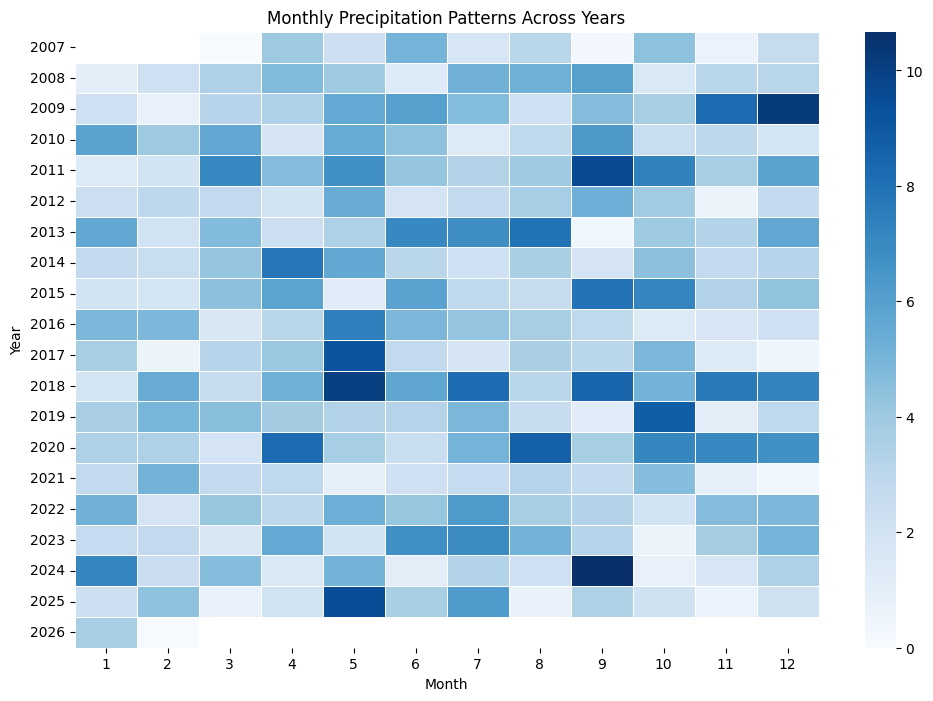

In [ ]:
# Group by year and month, sum or average precipitation per month
df['year'] = df['Date'].dt.year
monthly_year = df.groupby(['year','month'])['PRCP (Inches)'].sum().unstack()

plt.figure(figsize=(12,8))
sns.heatmap(monthly_year, cmap="Blues", linewidths=0.5)
plt.title("Monthly Precipitation Patterns Across Years")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()